# Pose experiment suite — real / synthetic / mixed

Classifiers evaluation for three distinct setups:

| Experiment | Pose | Synthetic IMU |
|---|---|---|
| `real_pose` | MotionBERT (real video) | real pipeline |
| `synthetic_pose` | Kimodo (generated from real windows) | Kimodo pipeline |
| `mixed_pose` | real + synthetic together | same as corresponding mode |

Each pose experiment runs exactly the same `run_experiment_suite` as the original notebook.

In [10]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / 'pose_module').exists() and (root / 'evaluation').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.classifiers import (
    ALL_CAPTURE_BLACKLIST,
    WindowedDatasetConfig,
    build_classifier_capture_table,
    build_windowed_multimodal_dataset,
)

from evaluation.classifiers import (
    EXPERIMENT_SPECS,
    ModelConfig,
    SplitConfig,
    TrainingConfig,
    run_experiment_suite,
)

from pose_module.robot_emotions.metadata import get_protocol_info
from evaluation.classifiers.metrics import plot_confusion_matrices

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 260)
PROJECT_ROOT

PosixPath('/home/henriquesouza/IMUGPT')

## Experiment Configuration

- `REAL_OUTPUT_ROOT` — real pipeline output directory (contains `virtual_imu_manifest.jsonl` + `imu.npz` per clip)
- `SYNTHETIC_MANIFEST` — manifest generated by `export-kimodo-virtual-imu`
- `MIXED_MANIFEST` — manifest generated by `export-mixed-virtual-imu`

In [ ]:
REAL_OUTPUT_ROOT     = PROJECT_ROOT / 'output' / 'exp_real_pose'
SYNTHETIC_MANIFEST   = PROJECT_ROOT / 'output' / 'exp_synthetic_pose' / 'virtual_imu_manifest.jsonl'
MIXED_MANIFEST       = PROJECT_ROOT / 'output' / 'exp_mixed_pose'      / 'mixed_virtual_imu_manifest.jsonl'
ANCHOR_CATALOG       = PROJECT_ROOT / 'output' / 'robot_emotions_kimodo_anchors_effectors_5' / 'kimodo_anchor_catalog.jsonl'

IMU_FEATURE_MODE = 'acc_euler'

# Emotions/stimuli manually excluded from classification (insufficient samples per subject)
EXCLUDED_EMOTIONS = {'Fear', 'Anger'}
EXCLUDED_STIMULI  = {}

DATASET_CONFIG = WindowedDatasetConfig(
    window_size=81,
    overlap=0.5,
    synthetic_variant='raw',
    imu_feature_mode=IMU_FEATURE_MODE,
    selected_sensors=None,
    max_windows_per_capture=None,
    random_state=42
)

SPLIT_CONFIG = SplitConfig(n_splits=5, random_state=42)
MODEL_CONFIG = ModelConfig(hidden_dim=128, dropout=0.1, trunk_blocks=2, modality_dropout_p=0.1)
TRAINING_CONFIG = TrainingConfig(
    batch_size=64, max_epochs=10, learning_rate=2e-3, weight_decay=1e-4,
    device='cuda',
    domain_loss_weight=0.1, flat_tag_loss_weight=0.3, emotion_loss_weight=1.0,
    modality_loss_weight=0.3, stimulus_loss_weight=0.3, use_cb_focal=False
)

REQUESTED_ORDER = [
    'vision_only', 'imu_only_r2r', 'imu_only_s2r', 'imu_only_mixed2r',
    'vision_imu_r2r', 'vision_imu_s2r', 'vision_imu_mixed2r'
]

print('REAL_OUTPUT_ROOT:', REAL_OUTPUT_ROOT)
print('SYNTHETIC_MANIFEST:', SYNTHETIC_MANIFEST)
print('MIXED_MANIFEST:', MIXED_MANIFEST)
print('ANCHOR_CATALOG:', ANCHOR_CATALOG)
print('EXCLUDED_EMOTIONS:', EXCLUDED_EMOTIONS)
print('EXCLUDED_STIMULI:', EXCLUDED_STIMULI)

REAL_OUTPUT_ROOT: /home/henriquesouza/IMUGPT/output/exp_real_pose
SYNTHETIC_MANIFEST: /home/henriquesouza/IMUGPT/output/exp_synthetic_pose/virtual_imu_manifest.jsonl
MIXED_MANIFEST: /home/henriquesouza/IMUGPT/output/exp_mixed_pose/mixed_virtual_imu_manifest.jsonl
ANCHOR_CATALOG: /home/henriquesouza/IMUGPT/output/robot_emotions_kimodo_anchors_effectors_5/kimodo_anchor_catalog.jsonl
EXCLUDED_EMOTIONS: {'Fear', 'Anger'}
EXCLUDED_STIMULI: {}


## Helpers for loading synthetic manifests

The synthetic manifest lacks `domain`/`user_id`/`tag_number` — these fields come from the real manifest
via `reference_clip_id`. The function below builds a capture table compatible with
`build_windowed_multimodal_dataset`.

In [ ]:
def _load_real_manifest_index(real_output_root: Path) -> pd.DataFrame:
    """Load real manifest and index by clip_id for metadata lookup."""
    path = real_output_root / 'virtual_imu_manifest.jsonl'
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        clip_dir = str(Path(e['artifacts']['virtual_imu_npz_path']).parent.parent.parent.resolve())
        rows.append({
            'clip_id':      str(e['clip_id']),
            'domain':       str(e['domain']),
            'user_id':      int(e['user_id']),
            'tag_number':   int(e['tag_number']),
            'take_id':      e.get('take_id'),
            'clip_dir':     clip_dir
        })
    return pd.DataFrame(rows).set_index('clip_id')

def _load_anchor_catalog_index(anchor_catalog_path: Path) -> dict[str, tuple[float, float]]:
    """Index anchor catalog by window_id → (start_sec, end_sec)."""
    index = {}
    for line in anchor_catalog_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        wid = e.get('window_id') or e.get('prompt_id')
        if wid and 'window' in e and e['window']:
            index[wid] = (float(e['window']['start_sec']), float(e['window']['end_sec']))
    return index

def _build_synthetic_capture_table(
    manifest_path: Path,
    real_index: pd.DataFrame,
    anchor_index: dict[str, tuple[float, float]],
    *,
    pose_kind_filter: str | None = None,
) -> pd.DataFrame:
    """
    Build capture table from a synthetic or mixed manifest.

    emotion/modality/stimulus come from get_protocol_info(domain, tag_number).

    Extra fields for per-fold recalibration:
      - virtual_imu_uncalibrated_npz_path: pre-calibration virtual signal
        (virtual_imu_geometric_aligned.npz for synthetic, None for pose_kind='real')
      - real_imu_reference_npz_path: imu.npz of the reference real clip,
        used to build the reference matrix restricted to training set
    """
    rows = []
    for line in manifest_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        if e.get('status') not in ('ok', 'warning'):
            continue
        pose_kind = e.get('pose_kind', 'synthetic')
        if pose_kind_filter is not None and pose_kind != pose_kind_filter:
            continue

        if pose_kind == 'real':
            artifacts = e.get('artifacts', {})
            pose3d_npz = artifacts.get('pose3d_npz_path')
            virtual_imu_npz = artifacts.get('virtual_imu_npz_path')
            uncalibrated_npz = None
            ref_clip_id = str(e['clip_id'])
        else:
            va = e.get('virtual_imu_artifacts', {})
            pose3d_npz = va.get('pose3d_npz_path')
            virtual_imu_npz = va.get('virtual_imu_npz_path')
            uncalibrated_npz = va.get('virtual_imu_npz_path')
            ref_clip_id = str(e.get('reference_clip_id') or e.get('clip_id'))

        if pose3d_npz is None or virtual_imu_npz is None:
            continue
        if not Path(pose3d_npz).exists() or not Path(virtual_imu_npz).exists():
            continue
        if ref_clip_id not in real_index.index:
            continue

        real_row = real_index.loc[ref_clip_id]
        real_imu_ref_path = str(Path(real_row['clip_dir']) / 'imu.npz')

        protocol = get_protocol_info(real_row['domain'], real_row['tag_number']) or {}
        emotion  = str(protocol.get('emotion', ''))
        modality = str(protocol.get('modality', ''))
        stimulus = str(protocol.get('stimulus', 'None'))

        window_id = e.get('window_id')
        real_imu_time_range_sec = anchor_index.get(window_id) if window_id else None

        sample_id = str(e.get('sample_id') or e.get('prompt_id') or e['clip_id'])
        rows.append({
            'clip_id':                            sample_id,
            'reference_clip_id':                  ref_clip_id,
            'domain':                             real_row['domain'],
            'user_id':                            real_row['user_id'],
            'tag_number':                         real_row['tag_number'],
            'take_id':                            real_row['take_id'],
            'emotion':                            emotion,
            'modality':                           modality,
            'stimulus':                           stimulus,
            'status':                             str(e.get('status', 'ok')),
            'pose3d_npz_path':                    pose3d_npz,
            'virtual_imu_npz_path':               virtual_imu_npz,
            'virtual_imu_uncalibrated_npz_path':  uncalibrated_npz,
            'real_imu_reference_npz_path':        real_imu_ref_path,
            'virtual_imu_frame_aligned_npz_path': None,
            'clip_dir':                           real_row['clip_dir'],
            'pose_kind':                          pose_kind,
            'quality_report':                     {},
            'real_imu_time_range_sec':            real_imu_time_range_sec
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df['subject_group'] = df.apply(lambda r: f"{r['domain']}_user_{int(r['user_id']):02d}", axis=1)
    df['flat_tag'] = df.apply(lambda r: f"{r['emotion']}|{r['modality']}|{r['stimulus']}", axis=1)
    df['frame_aligned_available'] = False
    n_with_range = df['real_imu_time_range_sec'].notna().sum()
    print(f'  real_imu_time_range_sec preenchido: {n_with_range}/{len(df)} amostras')
    n_uncal = df['virtual_imu_uncalibrated_npz_path'].notna().sum()
    print(f'  virtual_imu_uncalibrated_npz_path preenchido: {n_uncal}/{len(df)} amostras')
    return df.reset_index(drop=True)

def _apply_exclusions(df: pd.DataFrame, excluded_emotions: set[str], excluded_stimuli: set[str]) -> pd.DataFrame:
    """Remove captures whose emotions or stimuli are in the exclusion lists."""
    if df.empty:
        return df
    mask = pd.Series(False, index=df.index)
    if excluded_emotions:
        emotion_mask = df['emotion'].isin(excluded_emotions)
        if emotion_mask.any():
            print(f'  Excluindo {int(emotion_mask.sum())} capturas com emoção em {excluded_emotions}')
        mask |= emotion_mask
    if excluded_stimuli:
        stimulus_mask = df['stimulus'].isin(excluded_stimuli)
        if stimulus_mask.any():
            print(f'  Excluindo {int(stimulus_mask.sum())} capturas com estímulo em {excluded_stimuli}')
        mask |= stimulus_mask
    return df.loc[~mask].reset_index(drop=True)

def _sort_suite_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    order_map = {name: idx for idx, name in enumerate(REQUESTED_ORDER)}
    df = summary_df.copy()
    df['_sort_key'] = df['experiment_name'].astype(str).map(order_map).fillna(len(REQUESTED_ORDER))
    return df.sort_values('_sort_key', kind='stable').drop(columns=['_sort_key']).reset_index(drop=True)


def _run_pose_experiment(label: str, captures_df: pd.DataFrame) -> dict:
    """Build dataset and run classifier suite for a capture table."""
    captures_df = _apply_exclusions(captures_df, EXCLUDED_EMOTIONS, EXCLUDED_STIMULI)

    display(Markdown(f'### {label} — dataset'))
    display(captures_df[['clip_id', 'domain', 'user_id', 'tag_number', 'emotion', 'modality', 'stimulus', 'status']].head())
    print({'num_captures': len(captures_df), 'domains': sorted(captures_df['domain'].unique().tolist())})

    dataset_bundle = build_windowed_multimodal_dataset(REAL_OUTPUT_ROOT, config=DATASET_CONFIG, captures_df=captures_df)
    display(dataset_bundle['metadata'].head())
    display(dataset_bundle['alignment_summary'].head())
    print({
        'num_samples':          len(dataset_bundle['metadata']),
        'pose_shape':           dataset_bundle['pose_windows'].shape,
        'imu_real_shape':       dataset_bundle['imu_real_windows'].shape,
        'imu_synthetic_shape':  dataset_bundle['imu_synthetic_windows'].shape
    })

    display(Markdown(f'### {label} — suite de classificadores'))
    suite_result = run_experiment_suite(
        dataset_bundle,
        experiment_names=list(EXPERIMENT_SPECS.keys()),
        split_config=SPLIT_CONFIG,
        model_config=MODEL_CONFIG,
        training_config=TRAINING_CONFIG
    )
    display(_sort_suite_summary(suite_result['summary']))
    display(suite_result['domain_gap_summary'])
    return {'label': label, 'dataset_bundle': dataset_bundle, 'suite_result': suite_result}


REAL_INDEX = _load_real_manifest_index(REAL_OUTPUT_ROOT)
ANCHOR_INDEX = _load_anchor_catalog_index(ANCHOR_CATALOG)
print(f'Real manifest index: {len(REAL_INDEX)} clips')
print(f'Anchor catalog index: {len(ANCHOR_INDEX)} windows')

Real manifest index: 89 clips
Anchor catalog index: 3726 janelas


---
## Per-fold synthetic IMU recalibration

For experiments with synthetic data (`imu_only_s2r`, `imu_only_mixed2r` and vision variants),
the original percentile calibration uses the full real IMU set as reference, including
test-set samples. This contaminates the synthetic signal with test distribution information.

The `_run_pose_experiment_fold_calibrated` function fixes this: before each fold, it rebuilds
`imu_synthetic_windows` applying calibration with reference restricted to the training subjects of that fold.

In [ ]:
from evaluation.classifiers.experiments import (
    build_subject_group_splits,
    run_single_experiment,
    _aggregate_oof_report,
    _build_oof_summary,
)
from evaluation.classifiers.metrics import (
    build_scored_class_ids,
    build_support_report,
    compute_domain_gap_summary,
    suite_results_frame,
    PRIMARY_HEADS,
)
from pose_module.processing.imu_calibration import build_calibration_reference_matrix, calibrate_virtual_imu_sequence
from evaluation.classifiers.features import build_imu_feature_tensor, resolve_imu_orientation_features
from evaluation.tsne import segment_signal_windows


def _build_train_real_imu_matrix(
    dataset_bundle: dict,
    train_capture_ids: set[str],
) -> np.ndarray:
    """
    Build real reference matrix [N, C] by concatenating acc signal from
    unique real imu.npz files associated with training clips.

    Deduplicated by real_imu_reference_npz_path to avoid loading the same
    file multiple times (multiple synthetic windows reference the same clip).
    """
    capture_table = dataset_bundle['capture_table']
    train_rows = capture_table[capture_table['clip_id'].isin(train_capture_ids)]

    seen_paths: set[str] = set()
    clip_npz_paths = []
    for _, row in train_rows.iterrows():
        ref_path = row.get('real_imu_reference_npz_path')
        if not ref_path or not Path(ref_path).exists():
            candidate = Path(row['clip_dir']) / 'imu.npz'
            if not candidate.exists():
                continue
            ref_path = str(candidate)
        if ref_path in seen_paths:
            continue
        seen_paths.add(ref_path)
        clip_npz_paths.append(ref_path)

    if not clip_npz_paths:
        raise RuntimeError('No training clip with a valid imu.npz found.')

    return build_calibration_reference_matrix(
        clip_npz_paths=clip_npz_paths,
        target_sensor_names=dataset_bundle['selected_sensors'],
        signal_mode='acc',
    )


def _recalibrate_synthetic_windows(
    dataset_bundle: dict,
    train_indices: np.ndarray,
) -> np.ndarray:
    """
    Rebuild imu_synthetic_windows with calibration restricted to training subjects.

    For each synthetic capture:
      1. Load virtual_imu.npz (raw signal — the pipeline no longer calibrates).
      2. Apply calibrate_virtual_imu_sequence with reference restricted to training clips.
      3. Rebuild IMU features and replace the corresponding windows.

    Captures without virtual_imu_uncalibrated_npz_path (pose_kind='real' in mixed)
    keep the original windows.
    """
    import tempfile, os
    metadata = dataset_bundle['metadata']
    capture_table = dataset_bundle['capture_table']
    imu_synthetic = np.array(dataset_bundle['imu_synthetic_windows'], dtype=np.float32)
    imu_feature_mode = dataset_bundle['imu_feature_mode']
    selected_sensors = dataset_bundle['selected_sensors']
    cfg = dataset_bundle['config']

    train_capture_ids = set(metadata.iloc[train_indices]['capture_id'].astype(str).tolist())
    real_matrix = _build_train_real_imu_matrix(dataset_bundle, train_capture_ids)

    # Save reference to a temporary NPZ so calibrate_virtual_imu_sequence can read it
    tmp = tempfile.NamedTemporaryFile(suffix='.npz', delete=False)
    tmp.close()
    try:
        np.savez(tmp.name,
                 imu=real_matrix.reshape(real_matrix.shape[0], len(selected_sensors), -1),
                 sensor_names=np.array(selected_sensors))

        cap_idx = capture_table.set_index('clip_id')

        for capture_id, window_indices in metadata.groupby('capture_id').groups.items():
            capture_id = str(capture_id)
            if capture_id not in cap_idx.index:
                continue
            cap_row = cap_idx.loc[capture_id]
            uncalibrated_path = cap_row.get('virtual_imu_uncalibrated_npz_path')
            if not uncalibrated_path or pd.isna(uncalibrated_path) or not Path(uncalibrated_path).exists():
                continue  # pose_kind='real' or missing file — keep original windows

            with np.load(uncalibrated_path, allow_pickle=True) as payload:
                raw_acc        = np.asarray(payload['acc'],           dtype=np.float32)
                raw_gyro       = np.asarray(payload['gyro'],          dtype=np.float32)
                timestamps_sec = np.asarray(payload['timestamps_sec'], dtype=np.float32)
                sensor_names_raw = [str(v) for v in np.asarray(payload['sensor_names']).tolist()]

            sel_indices = [sensor_names_raw.index(s) for s in selected_sensors if s in sensor_names_raw]
            if len(sel_indices) != len(selected_sensors):
                continue
            acc_sel  = raw_acc[:,  sel_indices, :]
            gyro_sel = raw_gyro[:, sel_indices, :]

            from pose_module.interfaces import VirtualIMUSequence
            seq = VirtualIMUSequence(
                clip_id=capture_id,
                fps=None,
                sensor_names=selected_sensors,
                acc=acc_sel,
                gyro=gyro_sel,
                timestamps_sec=timestamps_sec,
                source='uncalibrated',
            )
            result = calibrate_virtual_imu_sequence(
                seq,
                real_imu_reference_path=tmp.name,
                signal_mode='acc',
            )
            calibrated_acc = np.asarray(result['virtual_imu_sequence'].acc, dtype=np.float32)

            imu_features = build_imu_feature_tensor(
                calibrated_acc, gyro_sel, timestamps_sec, feature_mode=imu_feature_mode
            )
            window_bundle = segment_signal_windows(
                imu_features['values'],
                window_type='n_samples',
                window_size=int(cfg.window_size),
                stride_or_overlap_mode='overlap',
                overlap=float(cfg.overlap)
            )
            new_windows = np.asarray(window_bundle['windows'], dtype=np.float32)

            window_idx_array = np.asarray(window_indices, dtype=np.int64)
            n_replace = min(len(window_idx_array), new_windows.shape[0])
            imu_synthetic[window_idx_array[:n_replace]] = new_windows[:n_replace]
    finally:
        os.unlink(tmp.name)

    return imu_synthetic


def _run_pose_experiment_fold_calibrated(label: str, captures_df: pd.DataFrame) -> dict:
    """
    Version of _run_pose_experiment with per-fold synthetic IMU recalibration.

    Before each fold, imu_synthetic_windows is rebuilt using only the
    real IMU from training subjects as percentile reference, eliminating
    the leakage from the original calibration that used the full set.
    """
    captures_df = _apply_exclusions(captures_df, EXCLUDED_EMOTIONS, EXCLUDED_STIMULI)

    display(Markdown(f'### {label} — dataset'))
    display(captures_df[['clip_id', 'domain', 'user_id', 'tag_number', 'emotion', 'modality', 'stimulus', 'status']].head())
    print({'num_captures': len(captures_df), 'domains': sorted(captures_df['domain'].unique().tolist())})

    dataset_bundle = build_windowed_multimodal_dataset( REAL_OUTPUT_ROOT, config=DATASET_CONFIG, captures_df=captures_df)
    display(dataset_bundle['metadata'].head())
    display(dataset_bundle['alignment_summary'].head())
    print({
        'num_samples':          len(dataset_bundle['metadata']),
        'pose_shape':           dataset_bundle['pose_windows'].shape,
        'imu_real_shape':       dataset_bundle['imu_real_windows'].shape,
        'imu_synthetic_shape':  dataset_bundle['imu_synthetic_windows'].shape
    })

    display(Markdown(f'### {label} — suite de classificadores (com recalibração por fold)'))

    experiment_names = list(EXPERIMENT_SPECS.keys())
    splits = build_subject_group_splits(dataset_bundle['metadata'], config=SPLIT_CONFIG)
    support_report = build_support_report(
        dataset_bundle['metadata'],
        dataset_bundle['label_encoders'],
        group_column=str(SPLIT_CONFIG.group_column),
        min_subject_groups=int(SPLIT_CONFIG.min_subject_groups_per_class)
    )
    scored_class_ids = build_scored_class_ids(support_report, head_names=PRIMARY_HEADS)

    results = []
    for split in splits:
        fold_id = int(split['split_id'])
        train_indices = np.asarray(split['train_indices'], dtype=np.int64)

        print(f'  Fold {fold_id + 1}/{len(splits)}: recalibrando IMU sintético...')
        recalibrated_synthetic = _recalibrate_synthetic_windows(dataset_bundle, train_indices)
        fold_bundle = {**dataset_bundle, 'imu_synthetic_windows': recalibrated_synthetic}

        split_with_context = {**split, 'num_splits': len(splits)}
        for experiment_name in experiment_names:
            results.append(
                run_single_experiment(
                    fold_bundle,
                    experiment_name=experiment_name,
                    split=split_with_context,
                    model_config=MODEL_CONFIG,
                    training_config=TRAINING_CONFIG,
                    scored_class_ids=scored_class_ids
                )
            )

    results_frame = suite_results_frame(results)
    oof_reports = {
        exp: _aggregate_oof_report(
            [r for r in results if r['experiment_name'] == exp],
            label_encoders=dataset_bundle['label_encoders'],
            scored_class_ids=scored_class_ids
        )
        for exp in experiment_names
    }
    oof_summary = _build_oof_summary(
        oof_reports,
        support_report=support_report,
        primary_head=str(SPLIT_CONFIG.primary_head)
    )
    suite_result = {
        'results': results,
        'results_frame': results_frame,
        'fold_diagnostics': results_frame,
        'summary': oof_summary,
        'oof_summary': oof_summary,
        'oof_reports': oof_reports,
        'support_report': support_report,
        'domain_gap_summary': compute_domain_gap_summary(oof_summary),
        'splits': splits
    }
    display(_sort_suite_summary(suite_result['summary']))
    display(suite_result['domain_gap_summary'])
    return {'label': label, 'dataset_bundle': dataset_bundle, 'suite_result': suite_result}

---
## Experiment 1 — Real pose only

Identical to the original notebook. Uses `build_classifier_capture_table` with the real manifest.

In [14]:
CAPTURES_REAL = build_classifier_capture_table(REAL_OUTPUT_ROOT)
RESULT_REAL   = _run_pose_experiment('real_pose', CAPTURES_REAL)

  Excluindo 4 capturas com emoção em {'Fear', 'Anger'}


### real_pose — dataset

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None,warning
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods,warning
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall,warning
3,robot_emotions_10ms_u02_tag07,10ms,2,7,Sadness,Standing,Autobiographical recall,warning
4,robot_emotions_10ms_u02_tag09,10ms,2,9,Happiness,Sitting,Visual methods,warning


{'num_captures': 76, 'domains': ['10ms', '30ms']}


,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01::window_0000,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,3,1,1,7
1,robot_emotions_10ms_u02_tag01::window_0001,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,3,1,1,7
2,robot_emotions_10ms_u02_tag01::window_0002,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,2,80,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,3,1,1,7
3,robot_emotions_10ms_u02_tag01::window_0003,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,3,120,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,3,1,1,7
4,robot_emotions_10ms_u02_tag01::window_0004,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,4,160,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,3,1,1,7


...

vision_imu_mixed2r | fold 5/5 | Epoch 8/10:   0%|          | 0/76 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 9/10:   0%|          | 0/76 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 10/10:   0%|          | 0/76 [00:00<?, ?batch/s]

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,num_samples
0,vision_only,0.540153,0.501353,0.384951,0.870554,0.364954,3903
1,imu_only_r2r,0.580711,0.556009,0.481904,0.766080,0.494150,3903
2,imu_only_s2r,0.426460,0.393284,0.293758,0.663464,0.322158,3903
3,imu_only_mixed2r,0.589728,0.560210,0.471657,0.784923,0.512603,3903
4,vision_imu_r2r,0.598714,0.560495,0.445839,0.869378,0.480924,3903
5,vision_imu_s2r,0.602043,0.560544,0.436050,0.891946,0.478132,3903
6,vision_imu_mixed2r,0.616808,0.579875,0.469077,0.893877,0.487471,3903


,metric,value
0,imu_only_gap_s2r,0.154251
1,imu_only_gap_mixed2r,-0.009016
2,imu_only_gain_mixed_over_r2r,0.009016
3,imu_only_gain_mixed_over_s2r,0.163268
4,vision_imu_gap_s2r,-0.003329
5,vision_imu_gap_mixed2r,-0.018095
6,vision_imu_gain_mixed_over_r2r,0.018095
7,vision_imu_gain_mixed_over_s2r,0.014766


---
## Experiment 2 — Synthetic pose only (Kimodo)

Each sample is a 5-second window generated by Kimodo from a real video window.
The real IMU still comes from the reference clip (required for alignment and labels).

In [15]:
CAPTURES_SYNTHETIC = _build_synthetic_capture_table(
    SYNTHETIC_MANIFEST, REAL_INDEX, ANCHOR_INDEX, pose_kind_filter='synthetic'
)
RESULT_SYNTHETIC   = _run_pose_experiment_fold_calibrated('synthetic_pose', CAPTURES_SYNTHETIC)

  real_imu_time_range_sec preenchido: 3722/3722 amostras
  virtual_imu_uncalibrated_npz_path preenchido: 3722/3722 amostras
  Excluindo 142 capturas com emoção em {'Fear', 'Anger'}


### synthetic_pose — dataset

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01__w000__s000,10ms,2,1,Neutrality,Standing,None,ok
1,robot_emotions_10ms_u02_tag01__w001__s000,10ms,2,1,Neutrality,Standing,None,ok
2,robot_emotions_10ms_u02_tag01__w002__s000,10ms,2,1,Neutrality,Standing,None,ok
3,robot_emotions_10ms_u02_tag01__w003__s000,10ms,2,1,Neutrality,Standing,None,ok
4,robot_emotions_10ms_u02_tag01__w004__s000,10ms,2,1,Neutrality,Standing,None,ok


{'num_captures': 3580, 'domains': ['10ms', '30ms']}


,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01__w000__s000::win...,robot_emotions_10ms_u02_tag01__w000__s000,robot_emotions_10ms_u02_tag01__w000__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-2,-0.066667,0.289946,0.807041,0.173103,0.0,0.0,0.0,0.0,3,1,1,7
1,robot_emotions_10ms_u02_tag01__w000__s000::win...,robot_emotions_10ms_u02_tag01__w000__s000,robot_emotions_10ms_u02_tag01__w000__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-2,-0.066667,0.289946,0.807041,0.173103,0.0,0.0,0.0,0.0,3,1,1,7
2,robot_emotions_10ms_u02_tag01__w001__s000::win...,robot_emotions_10ms_u02_tag01__w001__s000,robot_emotions_10ms_u02_tag01__w001__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",8,0.266666,0.293608,0.788759,0.182849,0.0,0.0,0.0,0.0,3,1,1,7
3,robot_emotions_10ms_u02_tag01__w001__s000::win...,robot_emotions_10ms_u02_tag01__w001__s000,robot_emotions_10ms_u02_tag01__w001__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",8,0.266666,0.293608,0.788759,0.182849,0.0,0.0,0.0,0.0,3,1,1,7
4,robot_emotions_10ms_u02_tag01__w002__s000::win...,robot_emotions_10ms_u02_tag01__w002__s000,robot_emotions_10ms_u02_tag01__w002__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",18,0.599999,0.205109,0.719723,0.190928,0.0,0.0,0.0,0.0,3,1,1,7


...

vision_imu_mixed2r | fold 5/5 | Epoch 8/10:   0%|          | 0/124 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 9/10:   0%|          | 0/124 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 10/10:   0%|          | 0/124 [00:00<?, ?batch/s]

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,num_samples
0,vision_only,0.553090,0.512773,0.391822,0.874534,0.392914,6249
1,imu_only_r2r,0.575984,0.549932,0.471776,0.772126,0.484049,6249
2,imu_only_s2r,0.351246,0.323739,0.241219,0.518939,0.293578,6249
3,imu_only_mixed2r,0.587339,0.560781,0.481106,0.791667,0.489245,6249
4,vision_imu_r2r,0.616406,0.581609,0.477218,0.893414,0.478587,6249
5,vision_imu_s2r,0.543623,0.500944,0.372907,0.872999,0.384962,6249
6,vision_imu_mixed2r,0.595014,0.559427,0.452667,0.884313,0.448062,6249


,metric,value
0,imu_only_gap_s2r,0.224738
1,imu_only_gap_mixed2r,-0.011356
2,imu_only_gain_mixed_over_r2r,0.011356
3,imu_only_gain_mixed_over_s2r,0.236094
4,vision_imu_gap_s2r,0.072784
5,vision_imu_gap_mixed2r,0.021392
6,vision_imu_gain_mixed_over_r2r,-0.021392
7,vision_imu_gain_mixed_over_s2r,0.051391


---
## Experiment 3 — Real + synthetic pose (mixed)

Concatenates the two sets above. Each entry keeps the `pose_kind` field for traceability.

In [16]:
CAPTURES_MIXED = _build_synthetic_capture_table(
    MIXED_MANIFEST, REAL_INDEX, ANCHOR_INDEX, pose_kind_filter=None
)
RESULT_MIXED   = _run_pose_experiment_fold_calibrated('mixed_pose', CAPTURES_MIXED)

  real_imu_time_range_sec preenchido: 3722/3809 amostras
  virtual_imu_uncalibrated_npz_path preenchido: 3722/3809 amostras
  Excluindo 146 capturas com emoção em {'Fear', 'Anger'}


### mixed_pose — dataset

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None,warning
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods,warning
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall,warning
3,robot_emotions_10ms_u02_tag07,10ms,2,7,Sadness,Standing,Autobiographical recall,warning
4,robot_emotions_10ms_u02_tag09,10ms,2,9,Happiness,Sitting,Visual methods,warning


{'num_captures': 3663, 'domains': ['10ms', '30ms']}


,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01::window_0000,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,3,1,1,7
1,robot_emotions_10ms_u02_tag01::window_0001,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,3,1,1,7
2,robot_emotions_10ms_u02_tag01::window_0002,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,2,80,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,3,1,1,7
3,robot_emotions_10ms_u02_tag01::window_0003,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,3,120,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,3,1,1,7
4,robot_emotions_10ms_u02_tag01::window_0004,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,4,160,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,3,1,1,7


...

vision_imu_mixed2r | fold 5/5 | Epoch 8/10:   0%|          | 0/200 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 9/10:   0%|          | 0/200 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 10/10:   0%|          | 0/200 [00:00<?, ?batch/s]

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,num_samples
0,vision_only,0.597208,0.557764,0.439432,0.916088,0.436103,10073
1,imu_only_r2r,0.591596,0.565588,0.487565,0.791268,0.495953,10073
2,imu_only_s2r,0.442789,0.408532,0.305760,0.658525,0.364081,10073
3,imu_only_mixed2r,0.579238,0.554169,0.478963,0.769507,0.489244,10073
4,vision_imu_r2r,0.621040,0.584374,0.474376,0.882554,0.506189,10073
5,vision_imu_s2r,0.603779,0.564006,0.444688,0.895002,0.471646,10073
6,vision_imu_mixed2r,0.625933,0.585452,0.464011,0.915422,0.498365,10073


,metric,value
0,imu_only_gap_s2r,0.148807
1,imu_only_gap_mixed2r,0.012358
2,imu_only_gain_mixed_over_r2r,-0.012358
3,imu_only_gain_mixed_over_s2r,0.136449
4,vision_imu_gap_s2r,0.017261
5,vision_imu_gap_mixed2r,-0.004893
6,vision_imu_gain_mixed_over_r2r,0.004893
7,vision_imu_gain_mixed_over_s2r,0.022154


---
## Comparison of the three experiments

In [17]:
frames = []
for result in (RESULT_REAL, RESULT_SYNTHETIC, RESULT_MIXED):
    if result['suite_result'] is None:
        continue
    df = _sort_suite_summary(result['suite_result']['summary']).copy()
    df.insert(0, 'pose_experiment', result['label'])
    frames.append(df)
if frames:
    display(pd.concat(frames, ignore_index=True))

,pose_experiment,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,num_samples
0,real_pose,vision_only,0.540153,0.501353,0.384951,0.870554,0.364954,3903
1,real_pose,imu_only_r2r,0.580711,0.556009,0.481904,0.766080,0.494150,3903
2,real_pose,imu_only_s2r,0.426460,0.393284,0.293758,0.663464,0.322158,3903
3,real_pose,imu_only_mixed2r,0.589728,0.560210,0.471657,0.784923,0.512603,3903
4,real_pose,vision_imu_r2r,0.598714,0.560495,0.445839,0.869378,0.480924,3903
5,real_pose,vision_imu_s2r,0.602043,0.560544,0.436050,0.891946,0.478132,3903
6,real_pose,vision_imu_mixed2r,0.616808,0.579875,0.469077,0.893877,0.487471,3903
7,synthetic_pose,vision_only,0.553090,0.512773,0.391822,0.874534,0.392914,6249
8,synthetic_pose,imu_only_r2r,0.575984,0.549932,0.471776,0.772126,0.484049,6249
9,synthetic_pose,imu_only_s2r,0.351246,0.323739,0.241219,0.518939,0.293578,6249


## Confusion matrices (best fold per experiment)

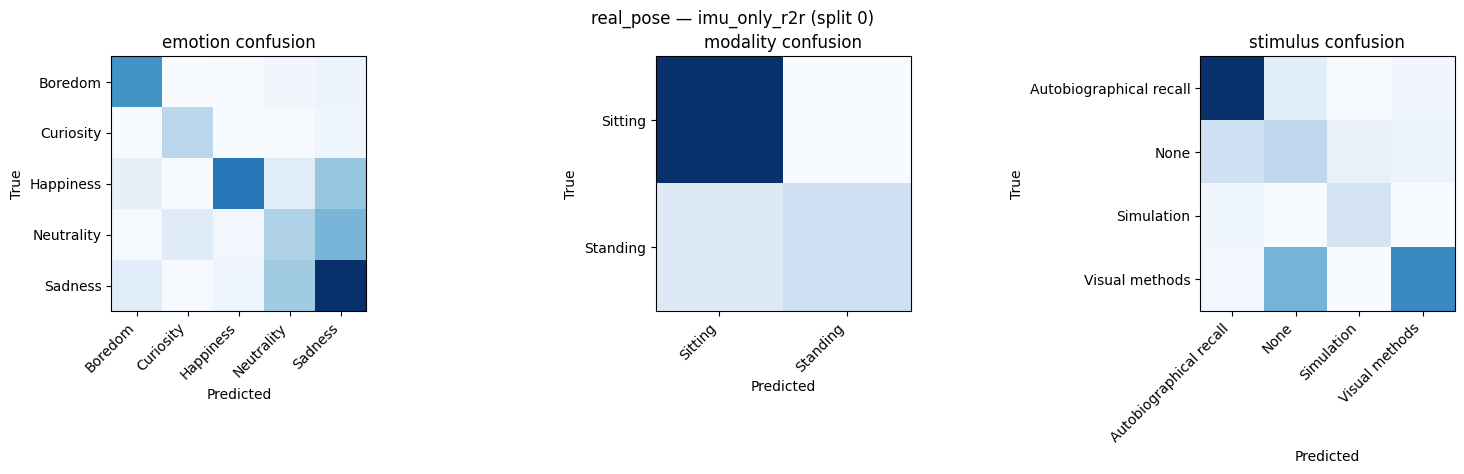

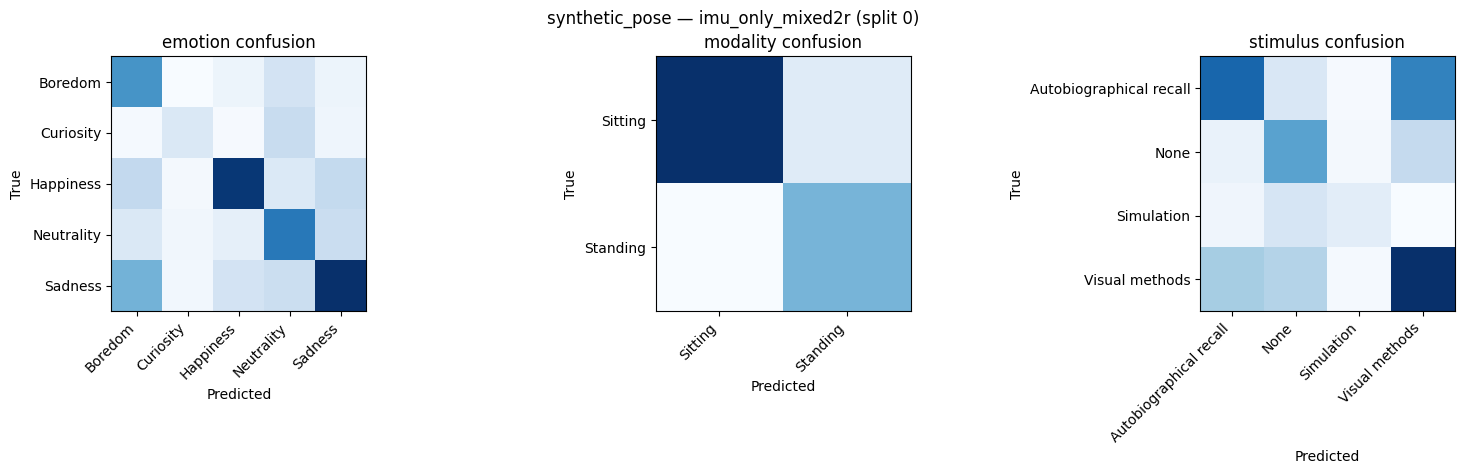

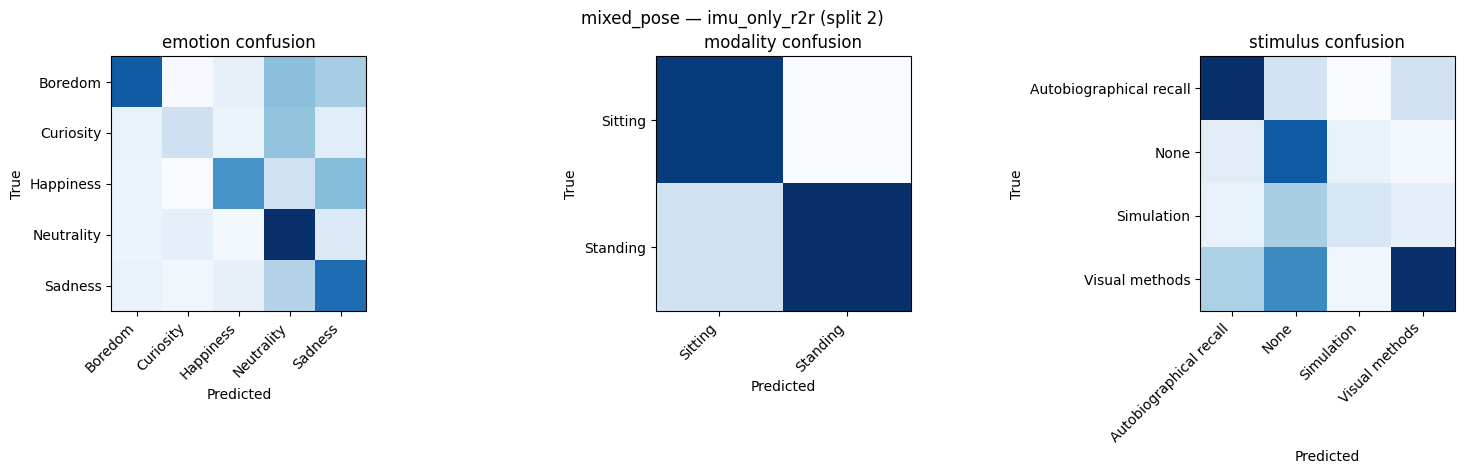

In [ ]:
for result in (RESULT_REAL, RESULT_SYNTHETIC, RESULT_MIXED):
    suite = result['suite_result']
    if suite is None:
        continue
    best_experiment_name = suite['summary'].iloc[0]['experiment_name']
    best_result = max(
        (r for r in suite['results'] if r['experiment_name'] == best_experiment_name),
        key=lambda r: float(r['metrics'].get('global_score_macro_f1_mean') or float('-inf'))
    )
    split_suffix = '' if best_result.get('split_id') is None else f" (split {best_result['split_id']})"
    fig, axes = plot_confusion_matrices(best_result['metrics'], result['dataset_bundle']['label_encoders'])
    fig.suptitle(f"{result['label']} — {best_experiment_name}{split_suffix}", y=1.02)
    plt.show()